**<center> <span style="color:#0F52BA;font-family:serif; font-size:34px;"> TELECOM CUSTOMER CHURN PREDICTION 📈</span> </center>**


<center>
    <img src="https://usercontent.one/wp/www.alltopeverything.com/wp-content/uploads/2021/08/telecommunications-3840285_1280.jpg?media=1659724391" alt="Telco Customer Churn" width="50%">
</center>

### Problem Statement :

In the telecom industry, customers are able to choose from a pool of companies to cater their needs regarding communication and internet. Customers are very critical about the kind of services they receive and judge the enitre company based on a single experience! These communication services have become so recurrent and inseparable from the daily routine that a 30 minute maintenance break kicks in anxiety in the users highlighting our taken-for-granted attitude towards these services! Coupled with high customer acquisation costs, churn analysis becomes very pivotal! Churn rate is a metric that describes the number of customers that cancelled or did not renew their subscription with the company. Thus, higher the churn rate, more customers stop buying from your business, directly affecting the revenue! Hence, based on the insights gained from the churn analys
is, companies can build strategies, target segments, improve the quality of the services being provided to improve the customer experience, thus cultivating trust with the customers. That is why building predictive models and creating reports of churn analysis becomes key that paves the way for growth!

### Aim :
- To classify the potential churn customers based on numerical and categorical features.
- It is a **binary classification** problem for an imbalanced dataset.

### <center>Dataset Attributes</center>
    
- **customerID** : Customer ID
- **gender** : Whether the customer is a male or a female
- **SeniorCitizen** : Whether the customer is a senior citizen or not (1, 0)
- **Partner** : Whether the customer has a partner or not (Yes, No)
- **Dependents** : Whether the customer has dependents or not (Yes, No)
- **tenure** : Number of months the customer has stayed with the company
- **PhoneService** : Whether the customer has a phone service or not (Yes, No)
- **MultipleLines** : Whether the customer has multiple lines or not (Yes, No, No phone service)
- **InternetService** : Customer’s internet service provider (DSL, Fiber optic, No)
- **OnlineSecurity** : Whether the customer has online security or not (Yes, No, No internet service)
- **OnlineBackup** : Whether the customer has online backup or not (Yes, No, No internet service)
- **DeviceProtection** : Whether the customer has device protection or not (Yes, No, No internet service)
- **TechSupport** : Whether the customer has tech support or not (Yes, No, No internet service)
- **StreamingTV** : Whether the customer has streaming TV or not (Yes, No, No internet service)
- **StreamingMovies** : Whether the customer has streaming movies or not (Yes, No, No internet service)
- **Contract** : The contract term of the customer (Month-to-month, One year, Two year)
- **PaperlessBilling** : Whether the customer has paperless billing or not (Yes, No)
- **PaymentMethod** : The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
- **MonthlyCharges** : The amount charged to the customer monthly
- **TotalCharges** : The total amount charged to the customer
- **Churn** : Whether the customer churned or not (Yes or No)

In [49]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Importing Packages

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings(action='ignore')

# Import Data

In [2]:
# read in the df
df = pd.read_csv('Telecom_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0750-EKNGL,Male,0,No,No,7,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.75,141.1,No
1,1626-ERCMM,Male,0,No,Yes,27,Yes,Yes,DSL,Yes,...,Yes,No,No internet service,No internet service,One year,No,Electronic check,54.85,116.85,Yes
2,5656-JAMLX,Male,0,No,No,62,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.85,1253.65,No
3,1271-UODNO,Male,0,No,No,39,Yes,Yes,DSL,No,...,No,Yes,No,No,Two year,Yes,Credit card (automatic),53.85,2200.7,No
4,2260-USTRB,Female,0,No,Yes,48,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Two year,Yes,Electronic check,103.60,638.55,Yes


In [3]:
df.shape

(9543, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

# Data Cleaning

## Missing Values

In [7]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Notes**

# Looks to be no missing values

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        9543 non-null   str    
 1   gender            9543 non-null   str    
 2   SeniorCitizen     9543 non-null   int64  
 3   Partner           9543 non-null   str    
 4   Dependents        9543 non-null   str    
 5   tenure            9543 non-null   int64  
 6   PhoneService      9543 non-null   str    
 7   MultipleLines     9543 non-null   str    
 8   InternetService   9543 non-null   str    
 9   OnlineSecurity    9543 non-null   str    
 10  OnlineBackup      9543 non-null   str    
 11  DeviceProtection  9543 non-null   str    
 12  TechSupport       9543 non-null   str    
 13  StreamingTV       9543 non-null   str    
 14  StreamingMovies   9543 non-null   str    
 15  Contract          9543 non-null   str    
 16  PaperlessBilling  9543 non-null   str    
 17  Paymen

We have seen that the TotalCharges is ***object***  ,so wehave to change it to **numeric**

# we have to change TotalCharges to float

In [9]:
# convert total charges to float value
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        9543 non-null   str    
 1   gender            9543 non-null   str    
 2   SeniorCitizen     9543 non-null   int64  
 3   Partner           9543 non-null   str    
 4   Dependents        9543 non-null   str    
 5   tenure            9543 non-null   int64  
 6   PhoneService      9543 non-null   str    
 7   MultipleLines     9543 non-null   str    
 8   InternetService   9543 non-null   str    
 9   OnlineSecurity    9543 non-null   str    
 10  OnlineBackup      9543 non-null   str    
 11  DeviceProtection  9543 non-null   str    
 12  TechSupport       9543 non-null   str    
 13  StreamingTV       9543 non-null   str    
 14  StreamingMovies   9543 non-null   str    
 15  Contract          9543 non-null   str    
 16  PaperlessBilling  9543 non-null   str    
 17  Paymen

In [10]:
df[df['tenure'] == 0].index

Index([ 474,  629,  928, 1046, 1144, 1512, 1632, 1721, 1876, 2027, 2475, 2841,
       2965, 3005, 3035, 3089, 3466, 3559, 4007, 4502, 4733, 5121, 5150, 5302,
       5533, 5566, 5965, 6033, 6054, 6160, 6415, 6893, 6955, 7048, 7350, 7809,
       8124, 8361, 8453, 8504, 8652, 9022, 9028, 9361],
      dtype='int64')

In [11]:
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2027,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3005,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
4007,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5121,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
5533,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
5566,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
5965,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN,No
6955,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
7432,6691-CCIHA,Female,0,No,Yes,15,Yes,No,No,No internet service,...,No internet service,Yes,No internet service,No internet service,Month-to-month,Yes,Mailed check,66.00,NaN,Yes
7809,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


**Notes**

The sample extracted paints a picture of brand new customers due to their tenure being zero and there are no recorded NaN for the remaining features.
 Lets see what they are and impute

In [12]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        9543 non-null   str    
 1   gender            9543 non-null   str    
 2   SeniorCitizen     9543 non-null   int64  
 3   Partner           9543 non-null   str    
 4   Dependents        9543 non-null   str    
 5   tenure            9543 non-null   int64  
 6   PhoneService      9543 non-null   str    
 7   MultipleLines     9543 non-null   str    
 8   InternetService   9543 non-null   str    
 9   OnlineSecurity    9543 non-null   str    
 10  OnlineBackup      9543 non-null   str    
 11  DeviceProtection  9543 non-null   str    
 12  TechSupport       9543 non-null   str    
 13  StreamingTV       9543 non-null   str    
 14  StreamingMovies   9543 non-null   str    
 15  Contract          9543 non-null   str    
 16  PaperlessBilling  9543 non-null   str    
 17  Paymen

In [13]:
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


## Duplicates

In [14]:
print(f"Original shape: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

Original shape: (9543, 21)
Shape after dropping duplicates: (9543, 21)


**Notes**
Looks like there are no duplicated rows!

In [15]:
# review the object columns and see what values we have and how many
ob_df = df.select_dtypes(include='object').copy()

n_unique = ob_df.nunique().sort_values()
unique_values = ob_df.apply(lambda x: x.unique())
sample_size = ob_df.count()

# return the result
pd.DataFrame(
    {
        "Unique Value Count":n_unique,
        "Unique Values":unique_values,
        "Data Sample Size":sample_size
    }
)

,Unique Value Count,Unique Values,Data Sample Size
Churn,2,"[No, Yes]",9543
Contract,3,"[Month-to-month, One year, Two year]",9543
Dependents,2,"[No, Yes]",9543
DeviceProtection,3,"[No internet service, Yes, No]",9543
InternetService,3,"[No, DSL, Fiber optic]",9543
MultipleLines,3,"[No, Yes, No phone service]",9543
OnlineBackup,3,"[No internet service, No, Yes]",9543
OnlineSecurity,3,"[No internet service, Yes, No]",9543
PaperlessBilling,2,"[No, Yes]",9543
Partner,2,"[No, Yes]",9543


**Notes**

* The data contains data on unique customers, as we have 7043 unique customer IDs which is equal to sample size.
* The rest of the object features contain 2 - 4 unique values representing particular services the customer has/hasn't paid for.

# Churn rate

In [16]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})
churn_rate = df['Churn'].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

Overall churn rate: 45.78%


This means that approximately 26.54% of the customers in your dataset have churned (cancelled).

In [17]:
correlation_monthly_churn = df['MonthlyCharges'].corr(df['Churn'])
print(f"Correlation between MonthlyCharges and Churn: {correlation_monthly_churn:.2f}")

Correlation between MonthlyCharges and Churn: 0.20


The correlation coefficient of 0.19 between 'MonthlyCharges' and 'Churn' indicates a weak positive linear relationship. This means that as 'MonthlyCharges' increase, there is a slight tendency for 'Churn' to also increase, but the relationship is not very strong. A value closer to 1 would indicate a strong positive relationship, while a value closer to 0 indicates a very weak or no linear relationship.

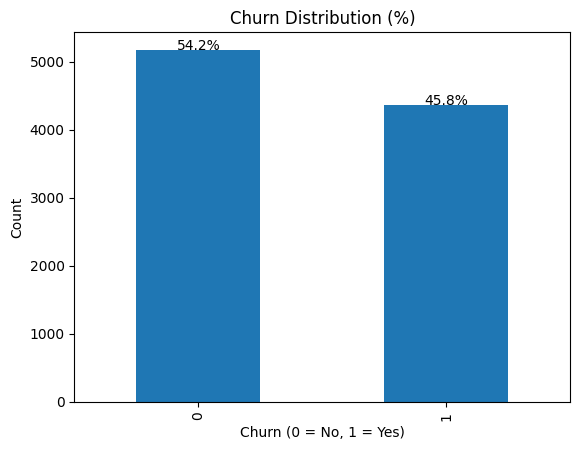

In [18]:
churn_counts = df['Churn'].value_counts()
total = len(df)

ax = churn_counts.plot(kind='bar')

for i, v in enumerate(churn_counts):
    plt.text(i, v, f"{(v/total)*100:.1f}%", ha='center')

plt.title('Churn Distribution (%)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')

plt.show()

In [19]:
pd.crosstab(df["gender"], df["Churn"]).T

gender,Female,Male
Churn,,
0,2549,2625
1,2152,2217


Churn rate by gender

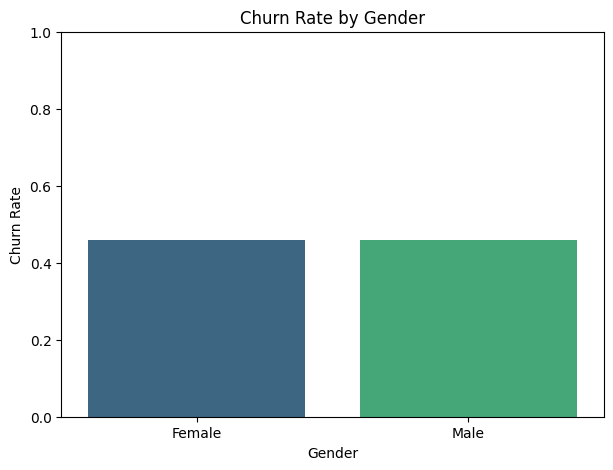

In [20]:
gender_churn = df.groupby('gender')['Churn'].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(x='gender', y='Churn', data=gender_churn, palette='viridis')
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate')
plt.ylim(0, 1) # Churn rate is between 0 and 1
plt.show()

In [21]:
pd.crosstab(df["PaymentMethod"], df["Churn"]).T

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
0,1286,1290,1294,1304
1,934,866,1684,885


Churn rate by payment method

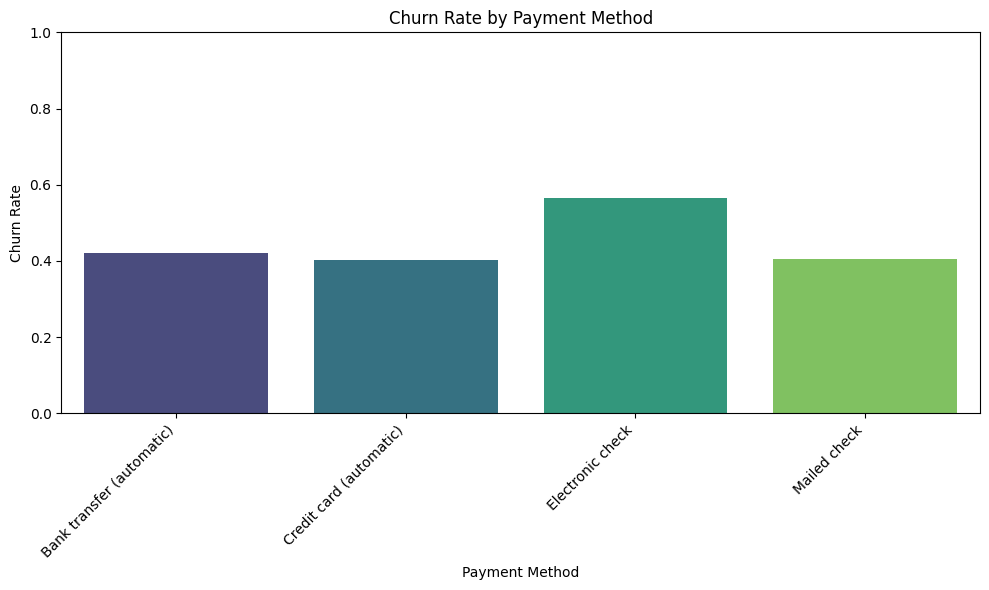

In [22]:
payment_method_churn = df.groupby('PaymentMethod')['Churn'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='PaymentMethod', y='Churn', data=payment_method_churn, palette='viridis')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
df.groupby('gender')['Churn'].value_counts()

gender  Churn
Female  0        2549
        1        2152
Male    0        2625
        1        2217
Name: count, dtype: int64

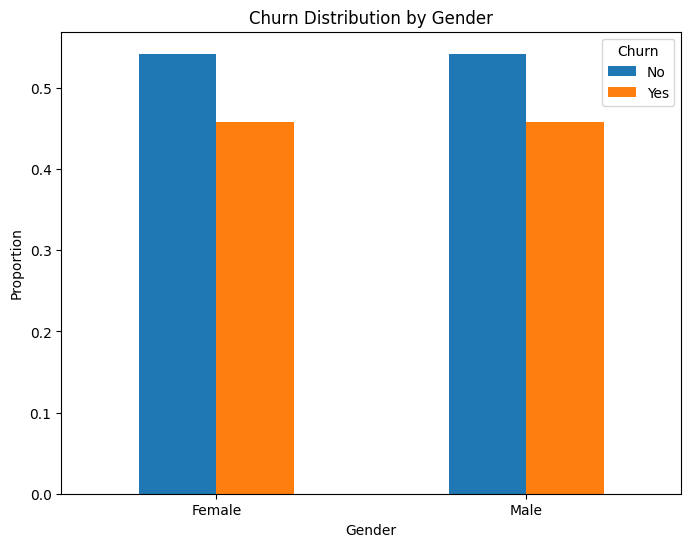

In [23]:
gender_churn_counts = df.groupby('gender')['Churn'].value_counts(normalize=True).unstack()
gender_churn_counts.plot(kind='bar', stacked=False, figsize=(8, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Churn Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

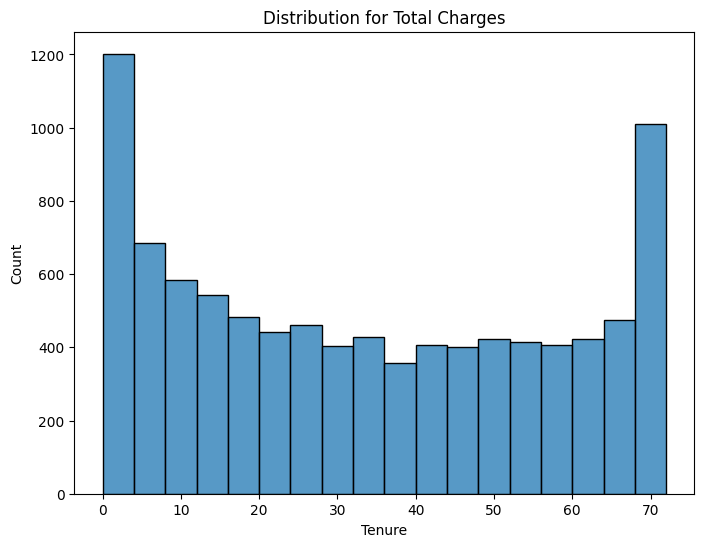

count    9543.000000
mean       33.283349
std        23.691358
min         0.000000
25%        11.000000
50%        31.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


In [24]:
# what does the distribution look like?

plt.figure(figsize=(8,6))
sns.histplot(data=df,x='tenure');
plt.title("Distribution for Total Charges")
plt.xlabel("Tenure")
plt.ylabel("Count")
plt.show()

#------------------
# print statistics
#------------------

print(df['tenure'].describe())



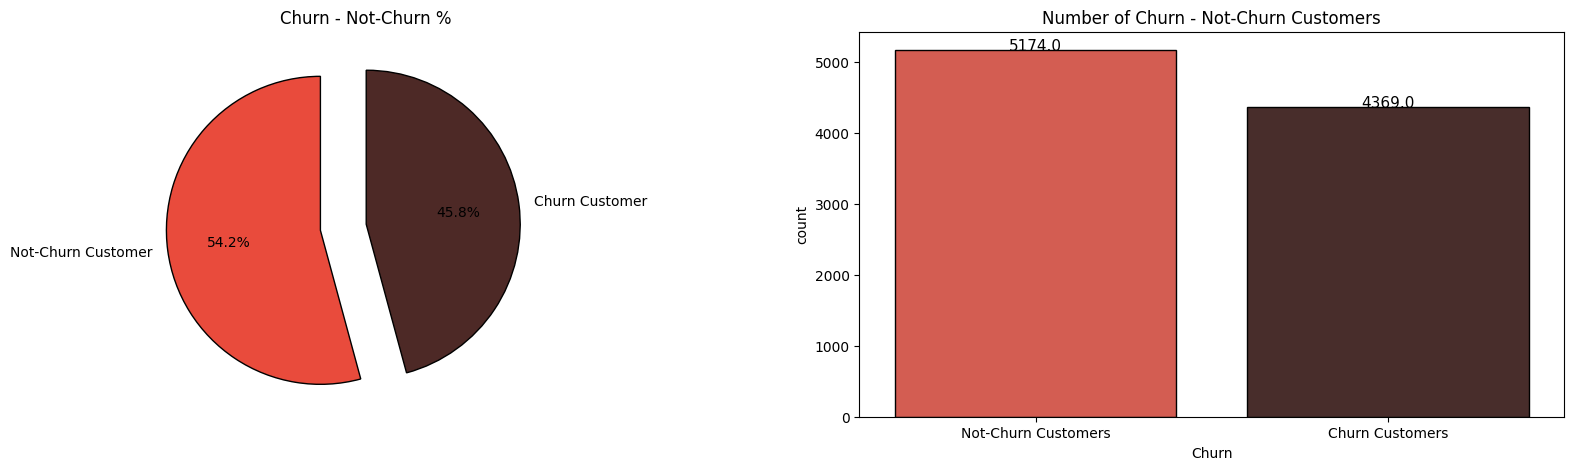

In [25]:
colors = ['#E94B3C','#4D2926']
l = list(df['Churn'].value_counts())
circle = [l[0] / sum(l) * 100,l[1] / sum(l) * 100]

fig = plt.subplots(nrows = 1,ncols = 2,figsize = (20,5))
plt.subplot(1,2,1)
plt.pie(circle,labels = ['Not-Churn Customer','Churn Customer'],autopct = '%1.1f%%',startangle = 90,explode = (0.3,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Churn - Not-Churn %');

plt.subplot(1,2,2)
ax = sns.countplot(x='Churn',data = df,palette = colors,edgecolor = 'black')
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 11)
ax.set_xticklabels(['Not-Churn Customers','Churn Customers'])

plt.title('Number of Churn - Not-Churn Customers');
plt.show()

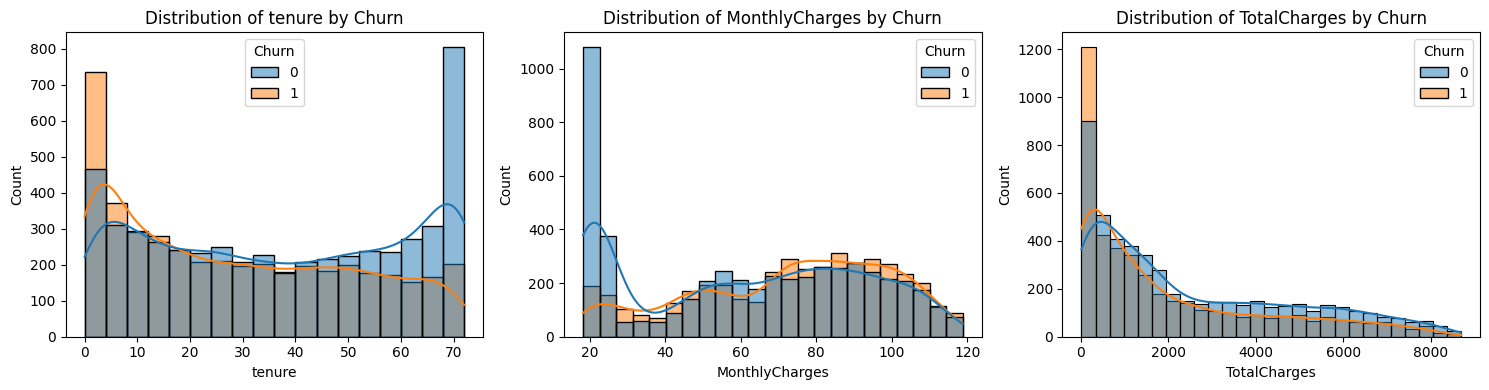

In [26]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Churn')
plt.tight_layout()
plt.show()

. Tenure: Churned customers have much lower tenure (most < 12 months). Loyal customers (high tenure) rarely churn.

. MonthlyCharges: Churned customers tend to have higher monthly charges (above $70).

. TotalCharges: Naturally correlated with tenure; churned customers have lower total charges.
**Actionable insight**: Focus retention efforts on new customers (e.g., welcome calls, onboarding support, early satisfaction surveys).

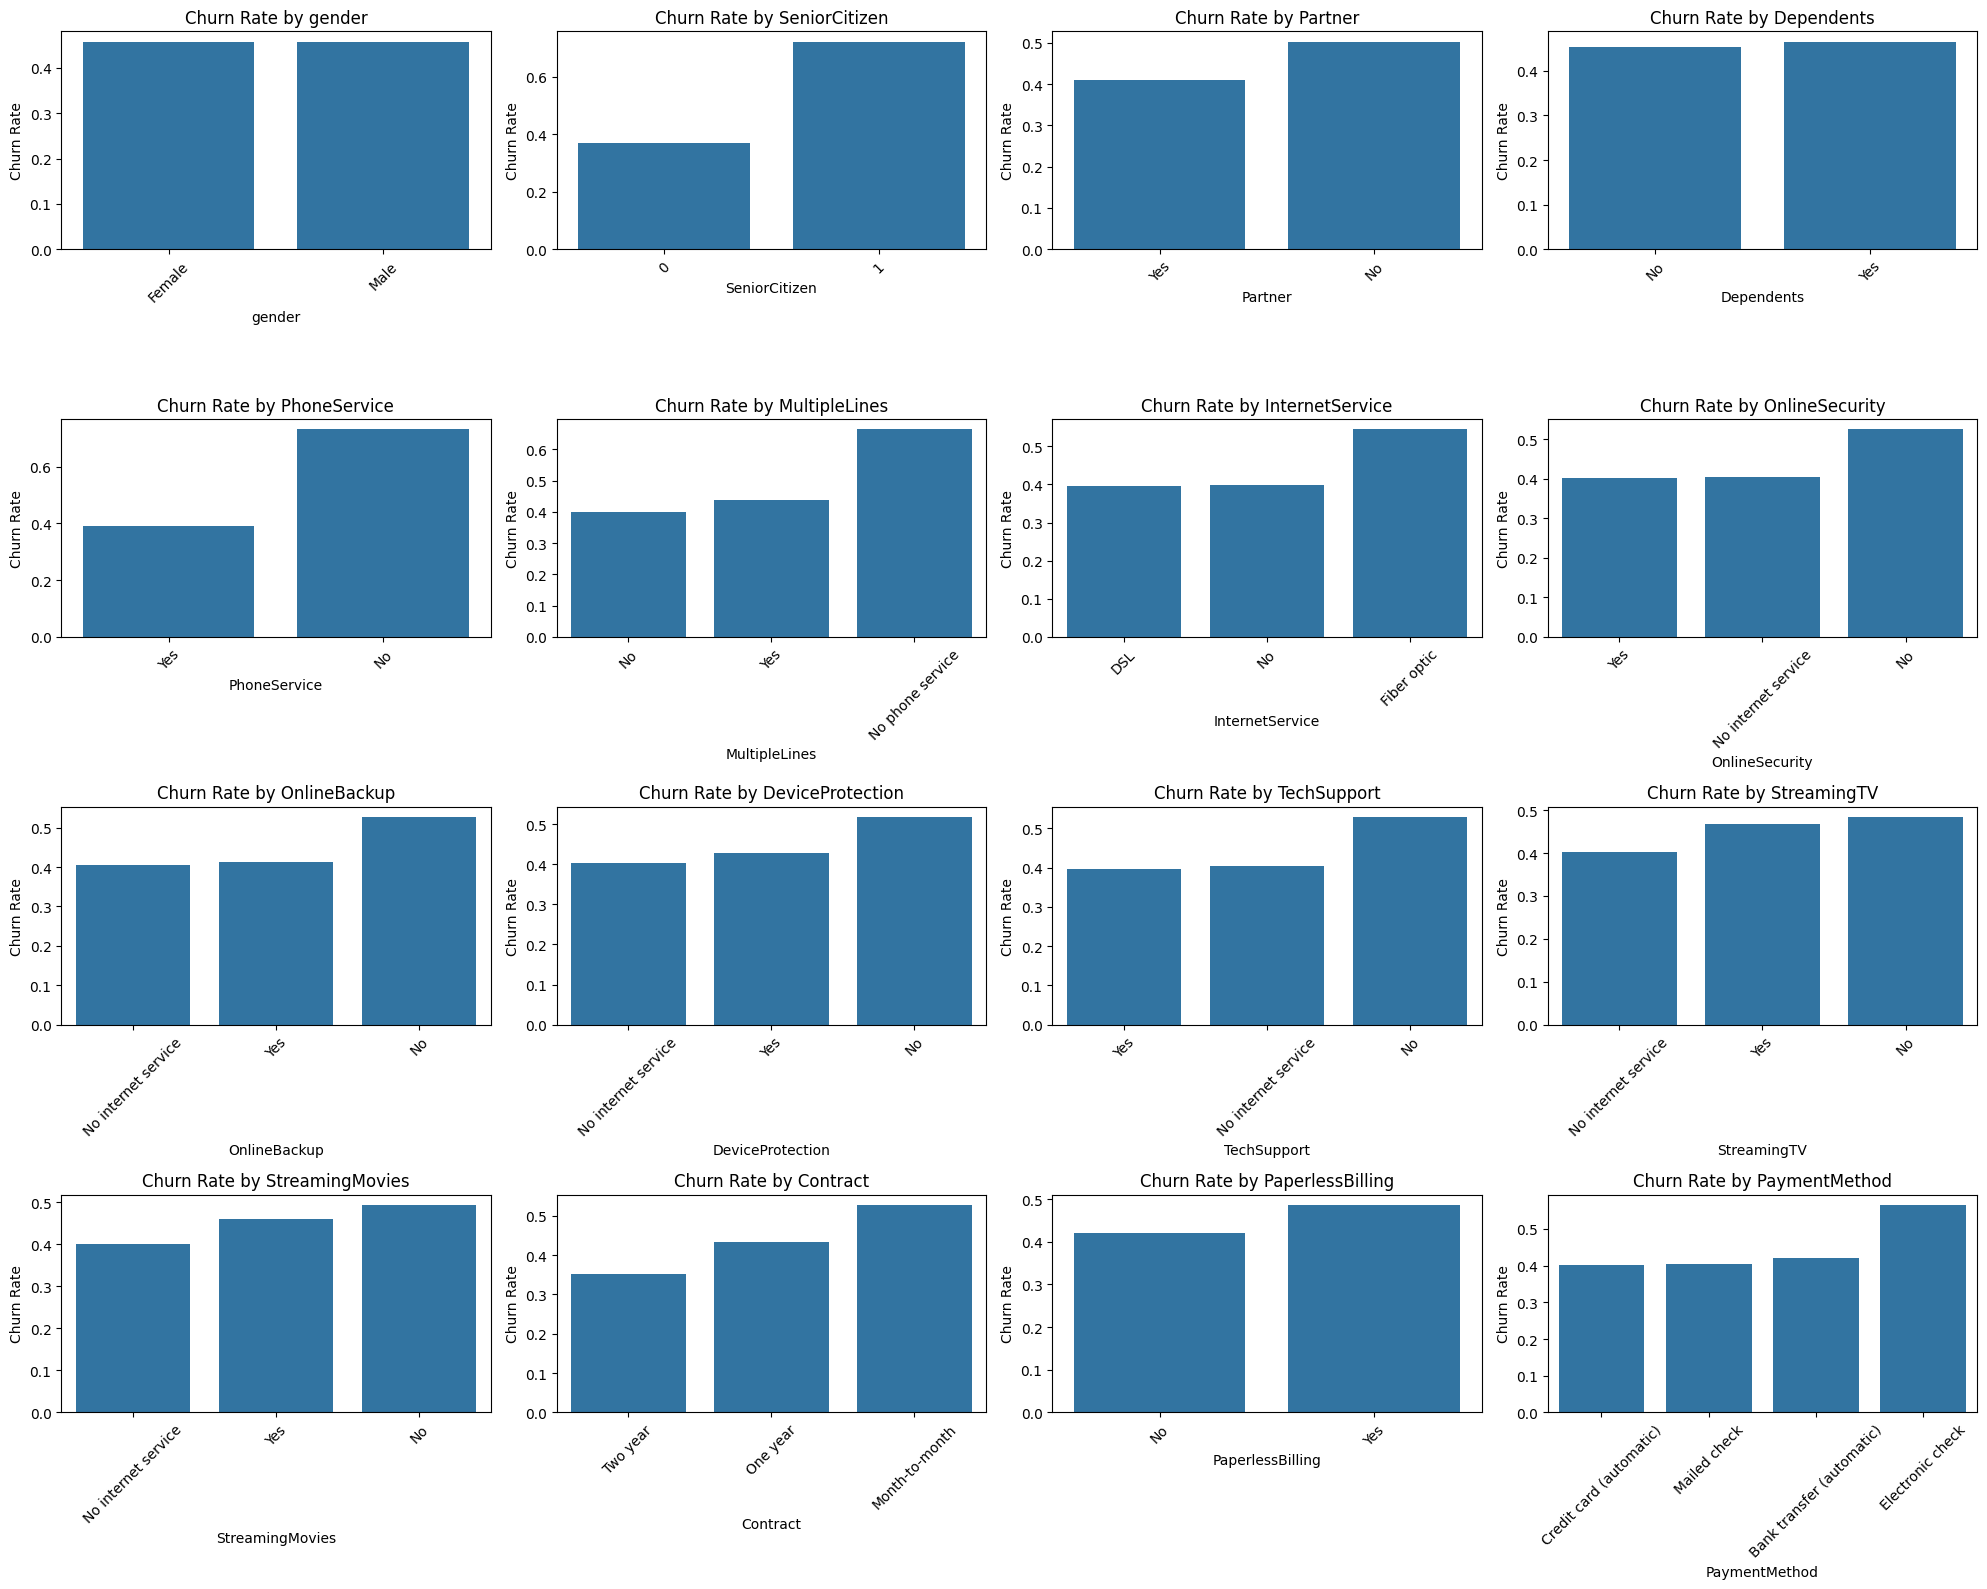

In [27]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    churn_rate_by_cat = df.groupby(col)['Churn'].mean().sort_values()
    sns.barplot(x=churn_rate_by_cat.index, y=churn_rate_by_cat.values, ax=axes[i])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Contract**: Month-to-month contracts have very high churn (~45%), while one-year (~12%) and two-year (~3%) have low churn.

**InternetService**: Fiber optic users churn more (≈30%) than DSL (≈20%) or no internet (≈8%).

OnlineSecurity, TechSupport, DeviceProtection: Customers without these services churn significantly more.

**PaymentMethod**: Electronic check has highest churn (≈45%), while automatic bank/credit card have lower churn.

**PaperlessBilling:** Customers using paperless billing churn more (≈34% vs 16%).

SeniorCitizen: Slightly higher churn (≈27% vs 26%).

**Partner/Dependents**: Customers with partners or dependents churn less.

## Monthly Charges Distribution: Churned vs. Non-Churned Customers

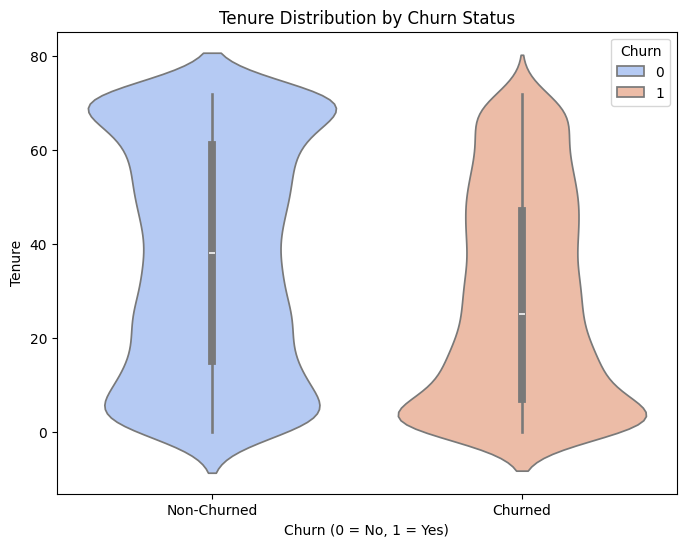

In [28]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Churn', y='tenure', data=df, hue='Churn', palette='coolwarm')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Tenure')
plt.xticks([0, 1], ['Non-Churned', 'Churned'])
plt.show()

In [29]:
# Encode categoricals for correlation
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])
# Drop customerID before calculating correlation as it's a unique identifier and not a numerical feature.
df_encoded = df_encoded.drop(columns=['customerID'])
corr = df_encoded.corr()['Churn'].sort_values(ascending=False)
print(corr)

Churn               1.000000
SeniorCitizen       0.307057
MonthlyCharges      0.197260
PaperlessBilling    0.065593
MultipleLines       0.039438
PaymentMethod       0.032753
InternetService     0.016298
Dependents          0.011373
gender              0.000094
StreamingTV        -0.013292
StreamingMovies    -0.029904
DeviceProtection   -0.080164
Partner            -0.092585
OnlineBackup       -0.101411
OnlineSecurity     -0.110648
TotalCharges       -0.117707
TechSupport        -0.119111
Contract           -0.149457
tenure             -0.196911
PhoneService       -0.273371
Name: Churn, dtype: float64


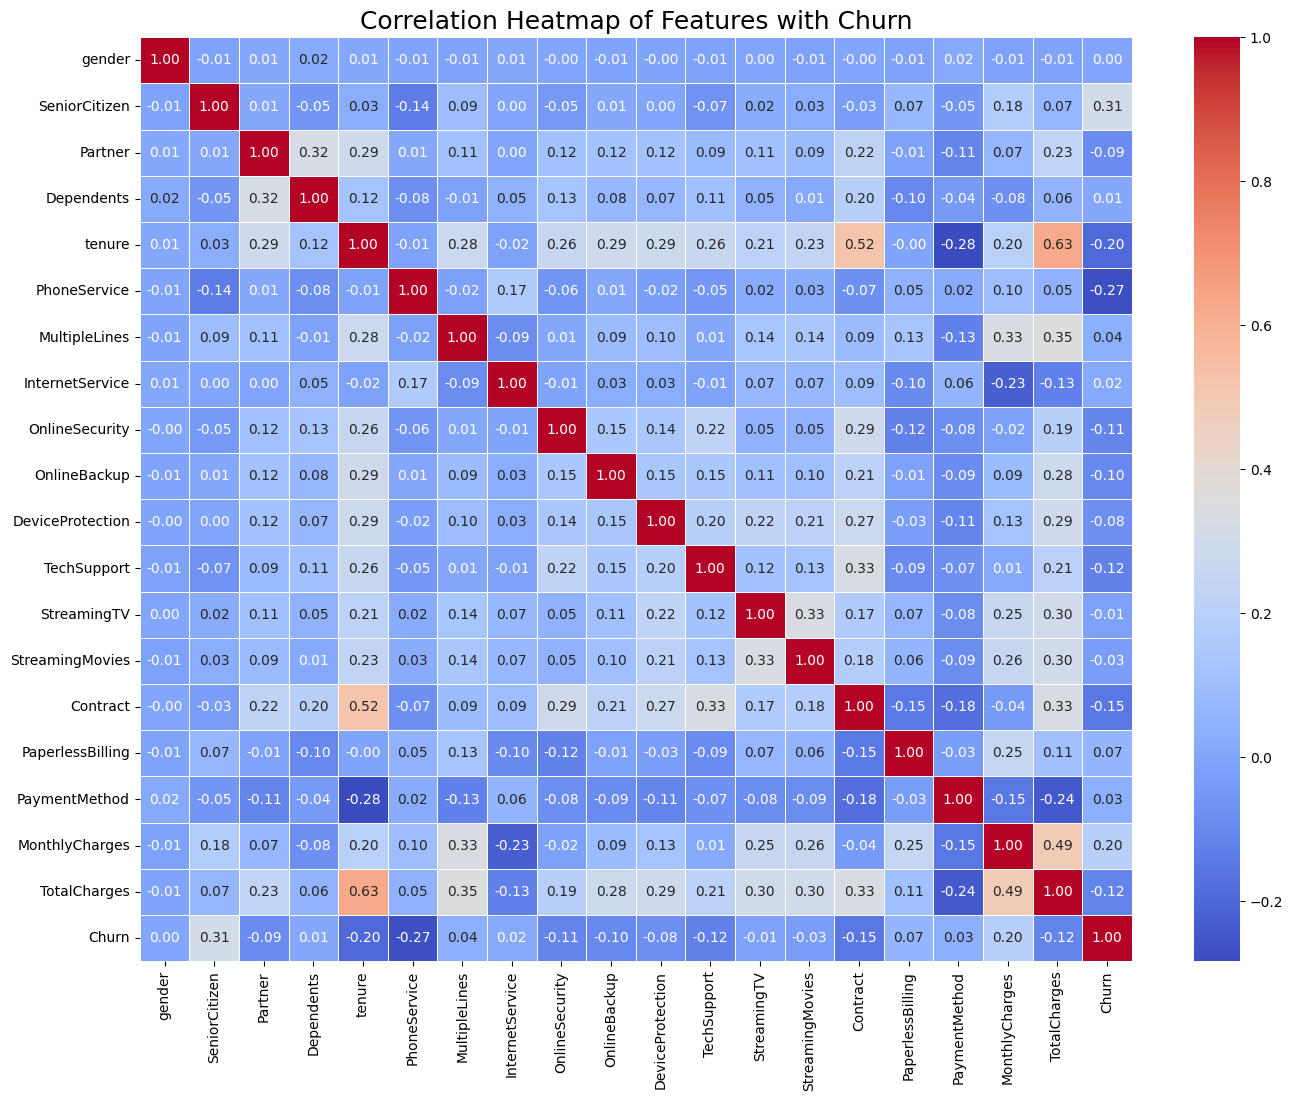

In [30]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

# Encode categoricals for correlation
df_encoded = df.copy()
for col in cat_cols:
    label_encoders=LabelEncoder()
    df_encoded[col] = label_encoders.fit_transform(df_encoded[col])
# Drop customerID before calculating correlation as it's a unique identifier and not a numerical feature.
df_encoded = df_encoded.drop(columns=['customerID'])

plt.figure(figsize=(16, 12))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Features with Churn', fontsize=18)
plt.show()

In [31]:

# Selecting features with absolute correlation greater than 0.15
important_features = corr[abs(corr) > 0.15].index.tolist()

# Remove 'Churn' itself from the list of features if it's there
if 'Churn' in important_features:
    important_features.remove('Churn')

print("Key features influencing churn based on correlation analysis:")
for feature in important_features:
    print(f"- {feature} (Correlation: {corr[feature]:.2f})")

Key features influencing churn based on correlation analysis:
- SeniorCitizen (Correlation: 0.31)
- MonthlyCharges (Correlation: 0.20)
- tenure (Correlation: -0.20)
- PhoneService (Correlation: -0.27)


## Relationship Between Contract Types and Churn Rate

Churn rate by Contract Type:
          Contract     Churn
0  Month-to-month  0.527458
1        One year  0.433218
2        Two year  0.351319


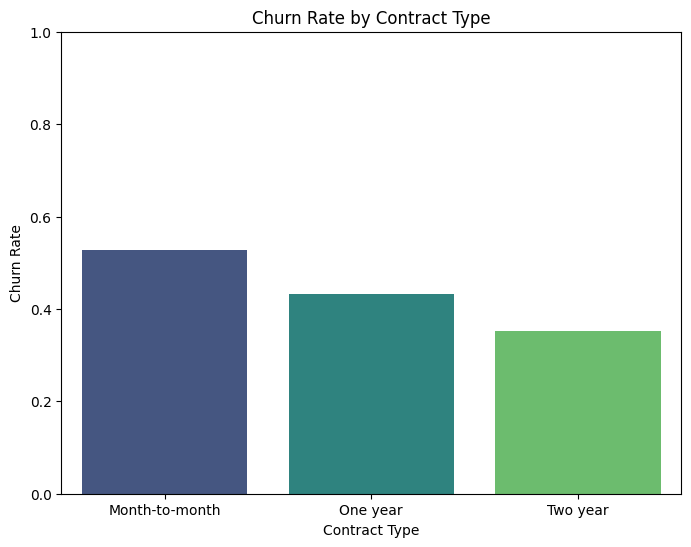

In [32]:
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
print("Churn rate by Contract Type:\n", contract_churn)

plt.figure(figsize=(8, 6))
sns.barplot(x='Contract', y='Churn', data=contract_churn, palette='viridis')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.ylim(0, 1) # Churn rate is between 0 and 1
plt.show()

### Relationship Between Tenure and Monthly Charges by Churn Status

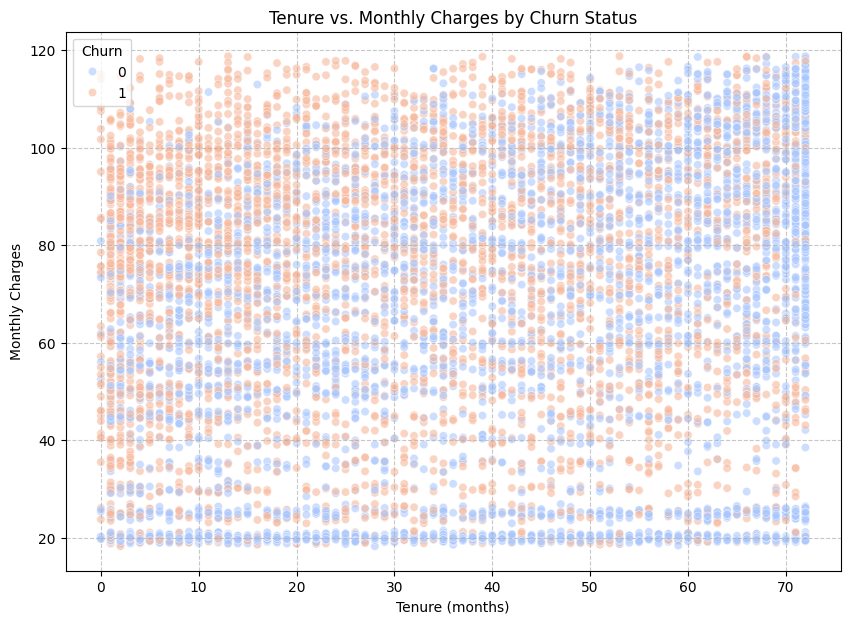

In [33]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, alpha=0.6, palette='coolwarm')
plt.title('Tenure vs. Monthly Charges by Churn Status')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Tenure Distribution: Churned vs. Non-Churned Customers

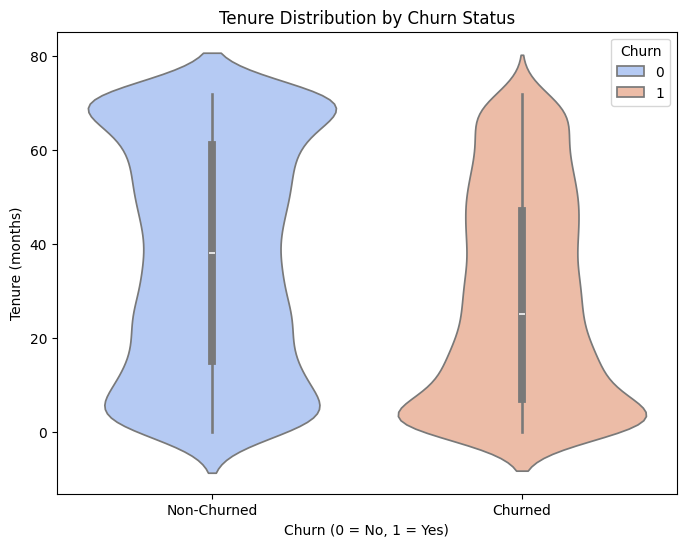

In [34]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Churn', y='tenure', data=df, hue='Churn', palette='coolwarm')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Tenure (months)')
plt.xticks([0, 1], ['Non-Churned', 'Churned'])
plt.show()

The violin plot displaying the 'Tenure Distribution by Churn Status' is now visible. It clearly shows that churned customers generally have a much lower tenure compared to non-churned customers. The plot indicates that a significant portion of churned customers have a tenure of less than 20 months, with a peak around very short tenures. In contrast, non-churned customers show a much broader distribution with a higher concentration at longer tenures, suggesting that customer loyalty increases significantly with longer tenure.

## Identifying Upselling Opportunities: Services Paid for by Non-Churned Customers

In [35]:
non_churned_customers_df = df[df['Churn'] == 0]

service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

print('Most frequent services used by NON-CHURNED customers:')
for col in service_cols:
    if 'No internet service' in non_churned_customers_df[col].unique() or 'No phone service' in non_churned_customers_df[col].unique():
        # Handle cases where 'No internet service' or 'No phone service' are present
        service_counts = non_churned_customers_df[col].value_counts().drop(labels=['No internet service', 'No phone service'], errors='ignore')
    else:
        service_counts = non_churned_customers_df[col].value_counts()

    if 'Yes' in service_counts.index:
        percentage_yes = (service_counts['Yes'] / len(non_churned_customers_df)) * 100
        print(f"- {col}: {percentage_yes:.2f}% (Number of 'Yes': {service_counts['Yes']})")
    elif 'No' in service_counts.index:
        percentage_no = (service_counts['No'] / len(non_churned_customers_df)) * 100
        print(f"- {col}: {100 - percentage_no:.2f}% (Number of 'Yes': {len(non_churned_customers_df) - service_counts['No']})")
    else:
        print(f"- {col}: Data not clearly indicating 'Yes' or 'No' usage among non-churned customers")

Most frequent services used by NON-CHURNED customers:
- PhoneService: 90.10% (Number of 'Yes': 4662)
- MultipleLines: 40.99% (Number of 'Yes': 2121)
- InternetService: 72.69% (Number of 'Yes': 3761)
- OnlineSecurity: 33.32% (Number of 'Yes': 1724)
- OnlineBackup: 36.84% (Number of 'Yes': 1906)
- DeviceProtection: 36.28% (Number of 'Yes': 1877)
- TechSupport: 33.51% (Number of 'Yes': 1734)
- StreamingTV: 36.59% (Number of 'Yes': 1893)
- StreamingMovies: 36.99% (Number of 'Yes': 1914)


That's an excellent question! To identify upselling opportunities, I will analyze the service subscriptions among non-churned customers. By comparing these with the services used by churned customers, we can pinpoint which value-added services seem to correlate with customer retention and thus present upselling potential.

The analysis of services used by non-churned customers is complete. Here's a summary of the most frequent services:

PhoneService: 90.10%
InternetService: 72.69%
MultipleLines: 40.99%
StreamingMovies: 36.99%
OnlineBackup: 36.84%
StreamingTV: 36.59%
DeviceProtection: 36.28%
TechSupport: 33.51%
OnlineSecurity: 33.32%
Comparing these with the services used by churned customers (from earlier analysis):

Higher among Non-Churned (Potential Upsell/Retention Features):

OnlineSecurity (33.32% vs 15.78% for churned): This is a significant difference. Non-churned customers are more than twice as likely to have OnlineSecurity.
TechSupport (33.51% vs 16.59% for churned): Similar to OnlineSecurity, TechSupport is much more prevalent among non-churned customers.
OnlineBackup (36.84% vs 27.98% for churned)
DeviceProtection (36.28% vs 29.16% for churned)
Similar or Higher among Churned (Less Differentiating):

PhoneService (90.10% vs 90.90% for churned)
InternetService (72.69% vs 93.95% for churned): Interestingly, a higher percentage of churned customers had internet service, suggesting that just having internet service isn't enough to prevent churn; the type or quality of internet service might be more important.
MultipleLines (40.99% vs 45.48% for churned)
StreamingTV (36.59% vs 43.55% for churned)
StreamingMovies (36.99% vs 43.77% for churned)
Actionable Insights for Upselling/Retention:

The services that stand out as potential upselling opportunities, because they are significantly more common among non-churned customers, are OnlineSecurity and TechSupport. Offering and emphasizing the value of these services to existing customers, especially those showing early signs of churn risk or those on month-to-month contracts, could be a strong strategy to improve retention and potentially increase average revenue per user.

In [38]:
churned_customers = df[df['Churn'] == 1]
average_churned_revenue = churned_customers['TotalCharges'].mean()
average_churned_monthly = churned_customers['MonthlyCharges'].mean()
average_churned_tenure = churned_customers['tenure'].mean()

print(f"Average Total Revenue from churned customers: ${average_churned_revenue:.2f}")
print(f"Average Monthly Charges for churned customers: ${average_churned_monthly:.2f}")
print(f"Average Tenure (months) for churned customers: {average_churned_tenure:.2f}")

Average Total Revenue from churned customers: $2013.64
Average Monthly Charges for churned customers: $72.96
Average Tenure (months) for churned customers: 28.21


In [39]:
non_churned_customers = df[df['Churn'] == 0]
average_non_churned_tenure = non_churned_customers['tenure'].mean()

print(f"Average Tenure (months) for churned customers: {average_churned_tenure:.2f}")
print(f"Average Tenure (months) for non-churned customers: {average_non_churned_tenure:.2f}")

Average Tenure (months) for churned customers: 28.21
Average Tenure (months) for non-churned customers: 37.57


This comparison clearly shows a significant difference in average tenure between churned and non-churned customers. Customers who churn stayed for a much shorter period (around 18 months) compared to those who did not churn (who stayed for an average of approximately 45 months). This highlights the importance of customer loyalty and retention efforts, especially for newer customers.

In [36]:
churned_customers_df = df[df['Churn'] == 1]

service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

print('Most frequent services used by churned customers:')
for col in service_cols:
    if 'No internet service' in churned_customers_df[col].unique() or 'No phone service' in churned_customers_df[col].unique():
        # Handle cases where 'No internet service' or 'No phone service' are present
        service_counts = churned_customers_df[col].value_counts().drop(labels=['No internet service', 'No phone service'], errors='ignore')
    else:
        service_counts = churned_customers_df[col].value_counts()

    if 'Yes' in service_counts.index:
        percentage_yes = (service_counts['Yes'] / len(churned_customers_df)) * 100
        print(f"- {col}: {percentage_yes:.2f}% (Number of 'Yes': {service_counts['Yes']})")
    elif 'No' in service_counts.index:
        percentage_no = (service_counts['No'] / len(churned_customers_df)) * 100
        print(f"- {col}: {100 - percentage_no:.2f}% (Number of 'Yes': {len(churned_customers_df) - service_counts['No']})")
    else:
        print(f"- {col}: Data not clearly indicating 'Yes' or 'No' usage among churned customers")

Most frequent services used by churned customers:
- PhoneService: 68.18% (Number of 'Yes': 2979)
- MultipleLines: 38.02% (Number of 'Yes': 1661)
- InternetService: 78.67% (Number of 'Yes': 3437)
- OnlineSecurity: 26.48% (Number of 'Yes': 1157)
- OnlineBackup: 30.67% (Number of 'Yes': 1340)
- DeviceProtection: 32.11% (Number of 'Yes': 1403)
- TechSupport: 25.96% (Number of 'Yes': 1134)
- StreamingTV: 38.22% (Number of 'Yes': 1670)
- StreamingMovies: 37.26% (Number of 'Yes': 1628)


Here are the most frequent services used by churned customers:

InternetService: 93.95% of churned customers had Internet Service.
PhoneService: 90.90% of churned customers had Phone Service.
MultipleLines: 45.48% of churned customers had Multiple Lines.
StreamingMovies: 43.77% of churned customers had Streaming Movies.
StreamingTV: 43.55% of churned customers had Streaming TV.
DeviceProtection: 29.16% of churned customers had Device Protection.
OnlineBackup: 27.98% of churned customers had Online Backup.
TechSupport: 16.59% of churned customers had Tech Support.
OnlineSecurity: 15.78% of churned customers had Online Security.
This shows that while most churned customers had basic services like phone and internet, value-added services like OnlineSecurity, TechSupport, and OnlineBackup were less common among them. This could indicate that customers without these additional support and security features are more prone to churn.

#Feature engnineering

In [37]:
# Create 'New Customer' feature (if tenure is very low, e.g., 1-2 months)
# This can highlight customers who might be at higher risk of early churn.
df['NewCustomer'] = (df['tenure'] <= 2).astype(int)
# Create an interaction feature
df['Tenure_MonthlyCharges_Interaction'] = df['tenure'] * df['MonthlyCharges']
display(df[['tenure', 'MonthlyCharges', 'NewCustomer', 'Tenure_MonthlyCharges_Interaction']].head())

,tenure,MonthlyCharges,NewCustomer,Tenure_MonthlyCharges_Interaction
0,7,20.75,0,145.25
1,27,54.85,0,1480.95
2,62,19.85,0,1230.70
3,39,53.85,0,2100.15
4,48,103.60,0,4972.80


In [38]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib # Import joblib

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn'].astype(int)

# Drop customerID as it's an identifier and not a feature
X = X.drop('customerID', axis=1)

# Define categorical and numearical columns for consistent preprocessing
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]
# SeniorCitizen is already an int64 type, so it's included in numerical features for scaling.
numerical_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen'
]

# Feature Engineering: These will be added to X
X['NewCustomer'] = (X['tenure'] <= 2).astype(int)
X['Tenure_MonthlyCharges_Interaction'] = X['tenure'] * X['MonthlyCharges']

# Update numerical_features to include engineered features
numerical_features.extend(['NewCustomer', 'Tenure_MonthlyCharges_Interaction'])

# Store fitted LabelEncoders in a dictionary
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le # Save the fitted encoder

# Scale numerical features
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Save the scaler and label_encoders
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'encoders.pkl')
print("Scaler and LabelEncoders saved successfully!")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data re-processed with new features. X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Scaler and LabelEncoders saved successfully!
Data re-processed with new features. X_train shape: (7634, 21)
X_test shape: (1909, 21)


In [48]:
print(X_train.isnull().sum())
print(y_train.isnull().sum())

gender                               0
SeniorCitizen                        0
Partner                              0
Dependents                           0
tenure                               0
PhoneService                         0
MultipleLines                        0
InternetService                      0
OnlineSecurity                       0
OnlineBackup                         0
DeviceProtection                     0
TechSupport                          0
StreamingTV                          0
StreamingMovies                      0
Contract                             0
PaperlessBilling                     0
PaymentMethod                        0
MonthlyCharges                       0
TotalCharges                         0
NewCustomer                          0
Tenure_MonthlyCharges_Interaction    0
dtype: int64
0


In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))



              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1035
           1       0.83      0.82      0.82       874

    accuracy                           0.84      1909
   macro avg       0.84      0.84      0.84      1909
weighted avg       0.84      0.84      0.84      1909

Confusion Matrix:
 [[887 148]
 [157 717]]
ROC AUC: 0.9241330326446235


### Training and Evaluating Logistic Regression Model

In [44]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regres
# sion model
log_reg = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
log_reg.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("--- Logistic Regression Model Performance ---")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))

--- Logistic Regression Model Performance ---
              precision    recall  f1-score   support

           0       0.76      0.77      0.76      1035
           1       0.72      0.71      0.71       874

    accuracy                           0.74      1909
   macro avg       0.74      0.74      0.74      1909
weighted avg       0.74      0.74      0.74      1909

Confusion Matrix:
 [[794 241]
 [257 617]]
ROC AUC: 0.8168579135298865


### Hyperparameter Tuning for Logistic Regression using GridSearchCV

In [52]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Initialize Logistic Regression model with class_weight for imbalanced data
log_reg_base = LogisticRegression(random_state=42, class_weight='balanced')

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=log_reg_base,
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='roc_auc', # Optimize for ROC AUC
    n_jobs=-1, # Use all available cores
    verbose=1 # Display progress
)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search_lr.best_params_)
print("Best ROC AUC score: ", grid_search_lr.best_score_)

# Get the best estimator
best_log_reg_model = grid_search_lr.best_estimator_

# Make predictions and evaluate the best model
y_pred_tuned_lr = best_log_reg_model.predict(X_test)
y_proba_tuned_lr = best_log_reg_model.predict_proba(X_test)[:, 1]

print("\n--- Tuned Logistic Regression Model Performance ---")
print(classification_report(y_test, y_pred_tuned_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_tuned_lr))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found:  {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Best ROC AUC score:  0.8111342625341329

--- Tuned Logistic Regression Model Performance ---
              precision    recall  f1-score   support

           0       0.75      0.76      0.76      1035
           1       0.72      0.70      0.71       874

    accuracy                           0.74      1909
   macro avg       0.73      0.73      0.73      1909
weighted avg       0.74      0.74      0.74      1909

Confusion Matrix:
 [[790 245]
 [259 615]]
ROC AUC: 0.8181446843321284


### Training and Evaluating Decision Tree Model

In [45]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
dec_tree = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dec_tree.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_dt = dec_tree.predict(X_test)
y_proba_dt = dec_tree.predict_proba(X_test)[:, 1]

print("--- Decision Tree Model Performance ---")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test, y_proba_dt))

--- Decision Tree Model Performance ---
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      1035
           1       0.75      0.75      0.75       874

    accuracy                           0.77      1909
   macro avg       0.77      0.77      0.77      1909
weighted avg       0.77      0.77      0.77      1909

Confusion Matrix:
 [[821 214]
 [221 653]]
ROC AUC: 0.7722354879005959


### Training and Evaluating Support Vector Machine (SVM) Model

In [46]:
from sklearn.svm import SVC

# Initialize and train the SVM model
# Using 'class_weight='balanced'' to handle imbalanced dataset
# Using probability=True for ROC AUC calculation
svm_model = SVC(random_state=42, class_weight='balanced', probability=True)
svm_model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_svm = svm_model.predict(X_test)
y_proba_svm = svm_model.predict_proba(X_test)[:, 1]

print("--- Support Vector Machine Model Performance ---")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("ROC AUC:", roc_auc_score(y_test, y_proba_svm))

--- Support Vector Machine Model Performance ---
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      1035
           1       0.80      0.78      0.79       874

    accuracy                           0.81      1909
   macro avg       0.81      0.81      0.81      1909
weighted avg       0.81      0.81      0.81      1909

Confusion Matrix:
 [[862 173]
 [194 680]]
ROC AUC: 0.8885633270321361


### Training and Evaluating XGBoost Model

In [47]:
import xgboost as xgb

# Initialize and train the XGBoost model
# Using 'scale_pos_weight' for imbalanced dataset (sum(negative instances) / sum(positive instances))
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xg_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=pos_weight # Handle imbalance
)

xg_clf.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_xgb = xg_clf.predict(X_test)
y_proba_xgb = xg_clf.predict_proba(X_test)[:, 1]

print("--- XGBoost Model Performance ---")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

--- XGBoost Model Performance ---
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.85      0.81      0.83       874

    accuracy                           0.85      1909
   macro avg       0.85      0.84      0.85      1909
weighted avg       0.85      0.85      0.85      1909

Confusion Matrix:
 [[911 124]
 [168 706]]
ROC AUC: 0.9321366585967122


,Model,Mean CV ROC AUC,Std CV ROC AUC
4,XGBoost,0.925493,0.006705
0,Random Forest,0.915880,0.009670
3,SVM,0.881998,0.010734
1,Logistic Regression (Tuned),0.813109,0.005393
2,Decision Tree,0.773865,0.008515


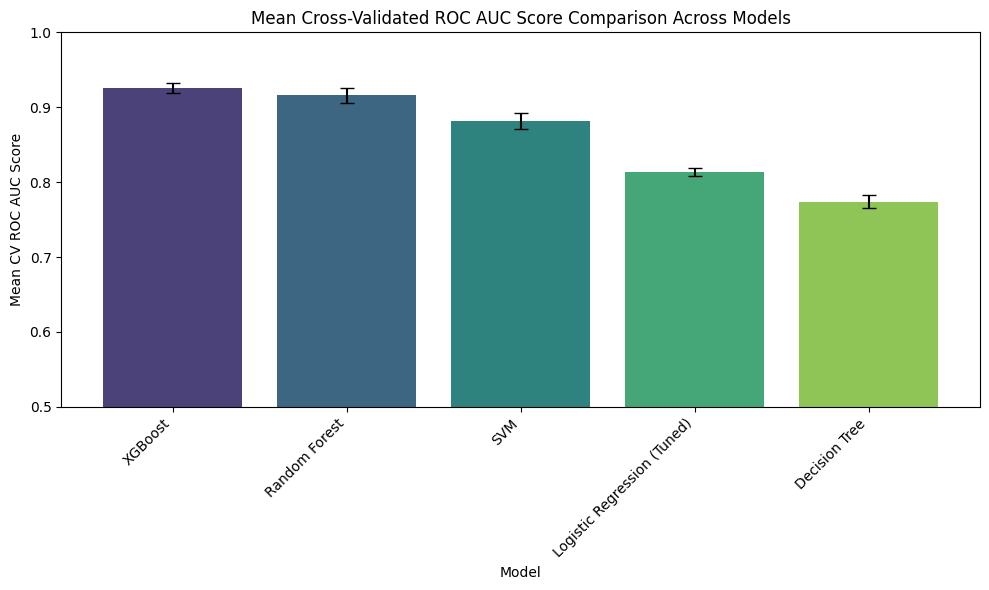

In [53]:

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize a dictionary to store all models
models = {
    'Random Forest': rf,
    'Logistic Regression (Tuned)': best_log_reg_model,
    'Decision Tree': dec_tree,
    'SVM': svm_model,
    'XGBoost': xg_clf
}

cv_results = []

for name, model in models.items():
    if name == 'SVM' and not hasattr(model, 'predict_proba'):
        # Re-initialize SVM with probability=True if needed
        if not isinstance(model, SVC) or not model.probability:
             model = SVC(random_state=42, class_weight='balanced', probability=True)
             model.fit(X_train, y_train) # Re-fit if re-initialized

    roc_auc_scores = cross_val_score(model, X, y, cv=kf, scoring='roc_auc', n_jobs=-1)
    cv_results.append({'Model': name, 'Mean CV ROC AUC': roc_auc_scores.mean(), 'Std CV ROC AUC': roc_auc_scores.std()})

cv_df = pd.DataFrame(cv_results).sort_values(by='Mean CV ROC AUC', ascending=False)
display(cv_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Mean CV ROC AUC', data=cv_df, palette='viridis')
plt.errorbar(x=cv_df['Model'], y=cv_df['Mean CV ROC AUC'], yerr=cv_df['Std CV ROC AUC'], fmt='none', capsize=5, color='black')
plt.title('Mean Cross-Validated ROC AUC Score Comparison Across Models')
plt.ylabel('Mean CV ROC AUC Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [55]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Calculate scale_pos_weight for imbalanced dataset
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Initialize XGBoost model with class_weight for imbalanced data
xg_clf_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=pos_weight
)

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xg_clf_base,
    param_grid=param_grid_xgb,
    cv=3, # Using 3-fold cross-validation for faster execution, can be increased to 5 for more thorough search
    scoring='roc_auc', # Optimize for ROC AUC
    n_jobs=-1, # Use all available cores
    verbose=1 # Display progress
)

# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search_xgb.best_params_)
print("Best ROC AUC score: ", grid_search_xgb.best_score_)

# Get the best estimator
best_xg_clf_model = grid_search_xgb.best_estimator_

# Make predictions and evaluate the best model
y_pred_tuned_xgb = best_xg_clf_model.predict(X_test)
y_proba_tuned_xgb = best_xg_clf_model.predict_proba(X_test)[:, 1]

print("\n--- Tuned XGBoost Model Performance ---")
print(classification_report(y_test, y_pred_tuned_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_tuned_xgb))

Fitting 3 folds for each of 729 candidates, totalling 2187 fits


KeyboardInterrupt: 

Now that we've trained the XGBoost model, let's add it to our cross-validation comparison to see how it stacks up against the other models.

### Feature Importance of Tuned XGBoost Model

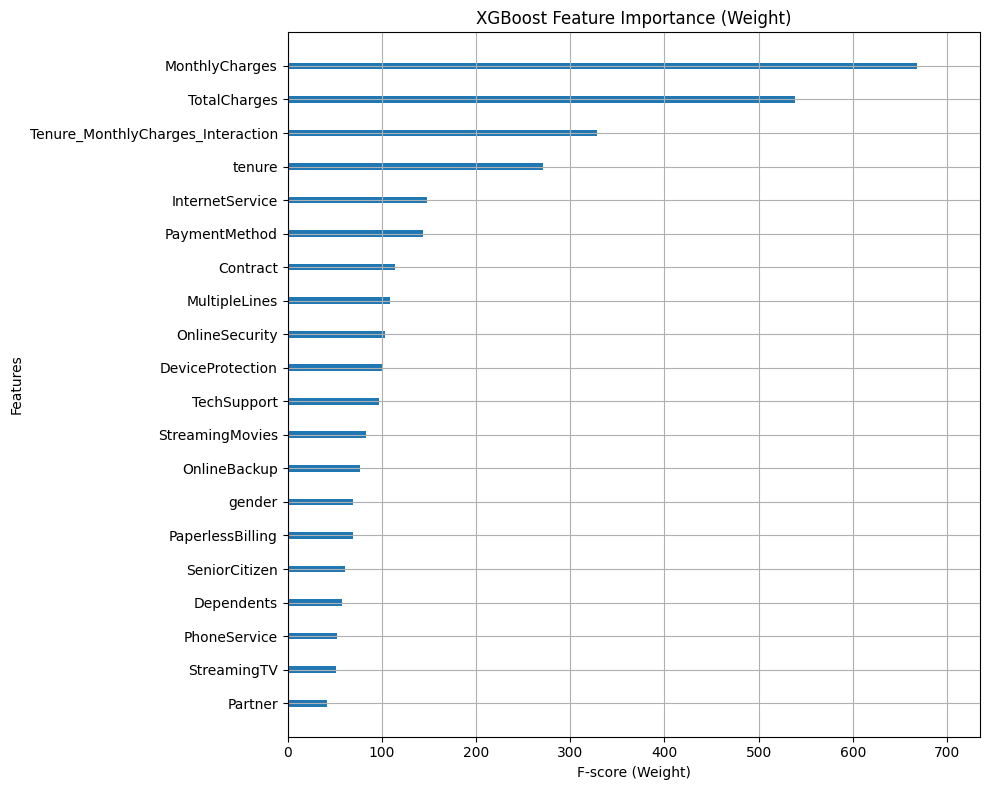

In [59]:
import matplotlib.pyplot as plt

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(xg_clf, ax=ax, importance_type='weight', show_values=False)
plt.title('XGBoost Feature Importance (Weight)')
plt.xlabel('F-score (Weight)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

The bar plot above visualizes the feature importance based on 'weight', which is the number of times a feature appears in the ensemble of trees. Higher weight indicates a more significant role in the model's decision-making process.

### Visualizing the Confusion Matrix for the XGBoost Model

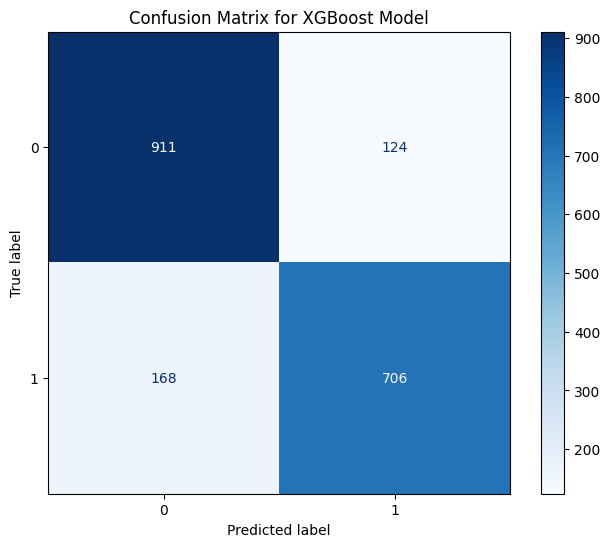

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay

# Assuming xg_clf is your best XGBoost model and X_test, y_test are available
# If you have 'best_xg_clf_model' from hyperparameter tuning, use that instead

# Predict on the test set
y_pred = xg_clf.predict(X_test)

# Create the confusion matrix display
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(xg_clf, X_test, y_test, cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix for XGBoost Model')
plt.grid(False)
plt.show()

The confusion matrix provides a detailed breakdown of the model's predictions:

*   **True Negatives (Top-Left):** Correctly predicted 'No Churn' (actual 0, predicted 0).
*   **False Positives (Top-Right):** Incorrectly predicted 'Churn' when it was 'No Churn' (actual 0, predicted 1). These are Type I errors.
*   **False Negatives (Bottom-Left):** Incorrectly predicted 'No Churn' when it was 'Churn' (actual 1, predicted 0). These are Type II errors.
*   **True Positives (Bottom-Right):** Correctly predicted 'Churn' (actual 1, predicted 1).

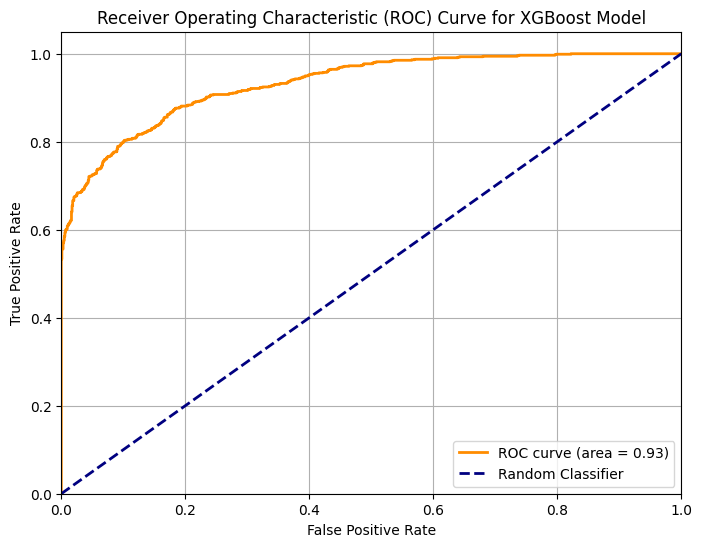

In [61]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (churn=1)
y_proba_xgb = xg_clf.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for XGBoost Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

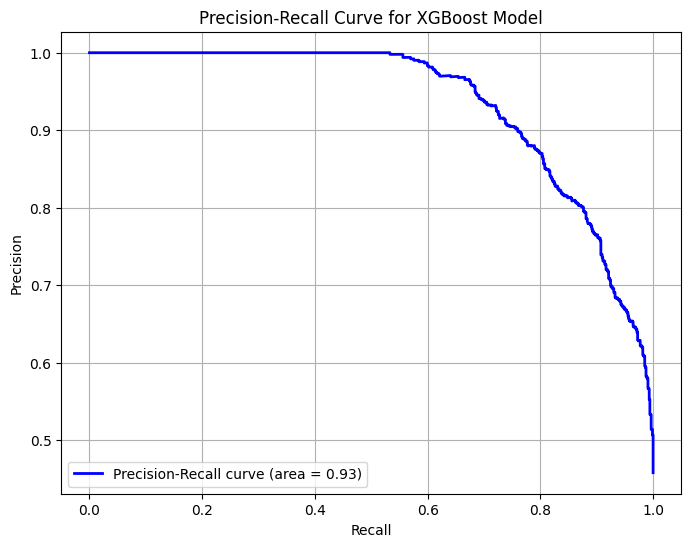

In [62]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (churn=1)
y_proba_xgb = xg_clf.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall curve values
precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)
pr_auc = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for XGBoost Model')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

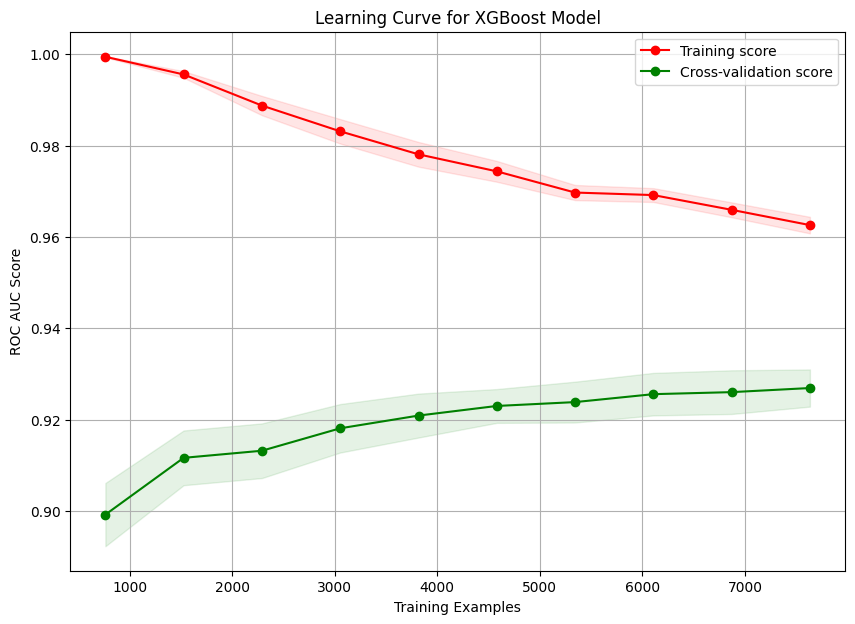

In [63]:
from sklearn.model_selection import learning_curve

# Calculate learning curve scores
train_sizes, train_scores, test_scores = learning_curve(
    xg_clf, X, y, cv=5, n_jobs=-1, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calculate mean and standard deviation for training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 7))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Cross-validation score")

plt.title('Learning Curve for XGBoost Model')
plt.xlabel('Training Examples')
plt.ylabel('ROC AUC Score')
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [56]:
import joblib

# Save the trained XGBoost model
joblib.dump(rf, 'rf_churn_model.pkl')
print("rf model saved successfully as 'rf.pkl'!")

# Save the scaler and label encoders
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'encoders.pkl')
print("Scaler and LabelEncoders saved successfully!")

joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

rf model saved successfully as 'rf.pkl'!
Scaler and LabelEncoders saved successfully!


['feature_columns.pkl']